# Packages

In [55]:
! pip install datasets plotly nbformat statsmodels seaborn matplotlib scipy numpy pandas scikit-learn -q



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.ticker as mtick

from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportion_confint

sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

# Données

### Première méthode: A partir d'une API

In [ ]:
import requests
import pandas as pd

url = "https://datasets-server.huggingface.co/rows"

all_rows = []

for offset in range(0, 1000, 100):
    params = {
        "dataset": "Uris001/credit-risk-eda",
        "config": "default",
        "split": "train",
        "offset": offset,
        "length": 100
    }

    response = requests.get(url, params=params).json()

    if "rows" not in response:
        break

    all_rows.extend([row["row"] for row in response["rows"]])

data = pd.DataFrame(all_rows)
print(data.head())

### Deuxième méthode

In [57]:
from datasets import load_dataset

ds = load_dataset("Uris001/credit-risk-eda")

data = ds["train"].to_pandas()
print(data.shape)

(31415, 16)


## Affichage de la base de donnée

In [58]:
data.head()

,Age,Annual Income,Home Ownership,Employment Length (Years),Loan Purpose,Loan Grade,Loan Amount,Interest Rate,Default Status,Loan % of Income,Previous Default,Credit History Length (Years),LTI Group,Income Group,Age Group,Interest Rate Group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,No,2,Low,Very Low,18–25,Medium
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,No,3,Very High,Very Low,18–25,High
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,No,2,Very High,High,18–25,Very High
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Yes,4,Very High,Medium,18–25,Very High
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,No,2,High,Very Low,18–25,Very Low


# Statistiques Descriptives

In [ ]:
data.info()

In [ ]:
import pandas as pd

# Format d'affichage des floats
pd.options.display.float_format = '{:,.2f}'.format

# Sélection dynamique des colonnes existantes
columns = [
    'Annual Income',
    'Loan Amount',
    'Interest Rate',
    'Loan % of Income',
    'Credit History Length (Years)'
]

cols_existantes = [col for col in columns if col in data.columns]

# Statistiques descriptives enrichies
summary = data[cols_existantes].describe().T

# Ajout de métriques utiles
summary['missing_values'] = data[cols_existantes].isnull().sum()
summary['skewness'] = data[cols_existantes].skew()

summary

,count,mean,std,min,25%,50%,75%,max,missing_values,skewness
Annual Income,"31,415.00","66,469.09","52,622.03","4,000.00","39,410.00","56,000.00","80,000.00","2,039,784.00",0,9.88
Loan Amount,"31,415.00","9,659.27","6,335.49",500.00,"5,000.00","8,000.00","12,500.00","35,000.00",0,1.18
Interest Rate,"31,415.00",11.04,3.20,5.42,7.90,10.99,13.48,23.22,0,0.21
Loan % of Income,"31,415.00",0.17,0.11,0.00,0.09,0.15,0.23,0.83,0,1.07
Credit History Length (Years),"31,415.00",5.82,4.06,2.00,3.00,4.00,8.00,30.00,0,1.66


In [ ]:
from statistique_descriptive import Statistique_Descriptives
from statistique_descriptive import analyse_categorielle


<span style="color:blue; font-size:36px; font-weight:bold;">
Objectif:
</span>

<span style="font-size:24px;">
L’objectif de cette étude consiste à identifier et à analyser les facteurs associés à une probabilité élevée de défaut de paiement d’un prêt.
</span>

# I. Statistiques descriptives Univariée

### Statistique descriptives sur le statut des clients

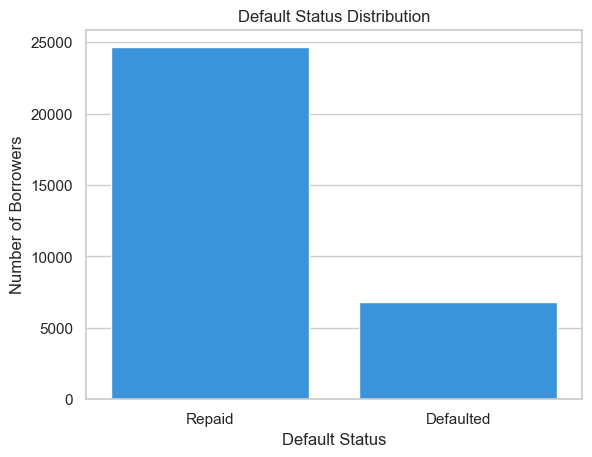

In [64]:
# This plot visualizes the distribution of the target variable (Default Status).
sns.countplot(x='Default Status', data=data, color='#2196F3')
plt.title('Default Status Distribution')
plt.xticks([0, 1], ['Repaid', 'Defaulted'])
plt.ylabel('Number of Borrowers')
plt.savefig("default_status_distribution.png", bbox_inches='tight', dpi=300)
plt.show()

Environ 21,5 % des clients de la banque sont en défaut de paiement, contre 78 % qui remboursent leurs prêts. Cela indique un déséquilibre du jeu de données, avec une majorité de cas de non-défaut.

Néanmoins, la proportion de défaut reste suffisamment élevée pour analyser les facteurs influençant le risque de crédit. Lors de la modélisation, il sera toutefois nécessaire de prendre en compte ce déséquilibre.

### Statistiques descriptives de l'Âge des clients

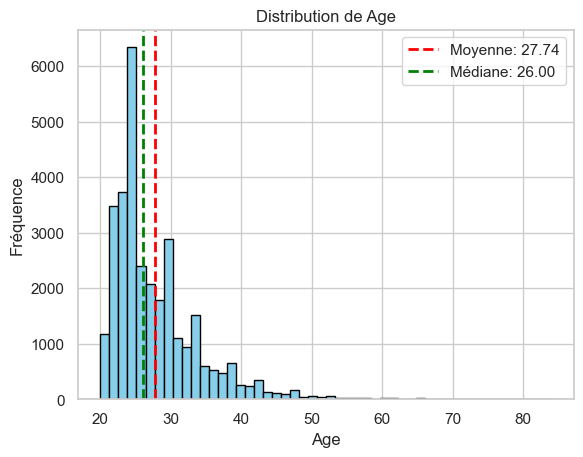

In [72]:
Statistique_Descriptives(data, "Age")

Un premier contrôle exploratoire montre que l'âge des individus est dans une fourchette assez raisonnable comprise entre 20 et 84 ans. Cela semble très normale vu la situation des individus et l'esperance de vie à la naissance. 

### Analyse du nombre d'année(s) de travail

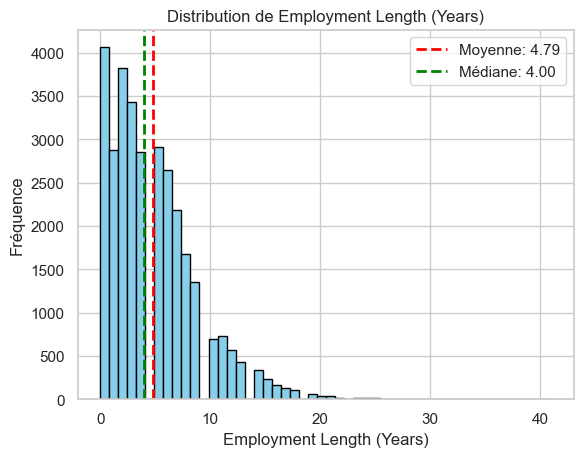

In [73]:
Statistique_Descriptives(data, "Employment Length (Years)")

Une analyse aussi de nombre d'année d'expérience des individus montre que cela est aussi normale avec la periode allant de 0 à 41 ans d'experience de travail.(<60 ans)

### Analyse des données des taux d'interet

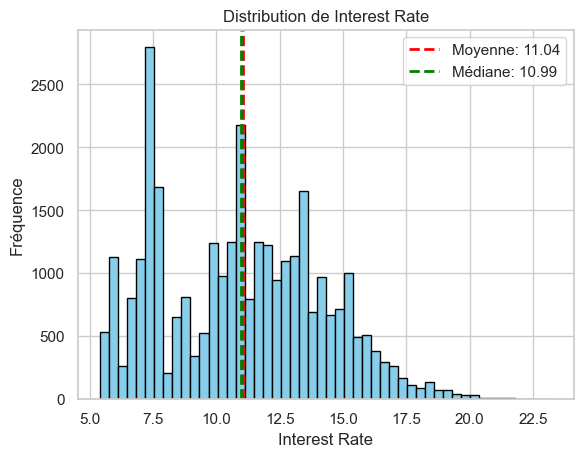

In [74]:
Statistique_Descriptives(data, "Interest Rate")

Les informations sur les taux d'interet montre que le mode est obtenus pour des valeurs proches de 7,5% ce qui reflète reellement la nature des taux d'interet sur les prèts bancaires. 

### Données sur les montants empruntés

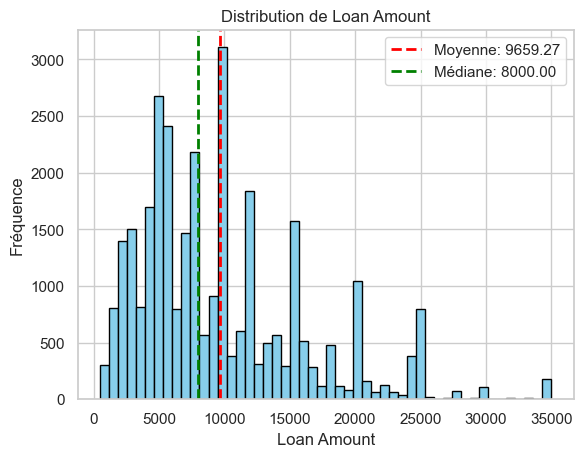

In [75]:
Statistique_Descriptives(data, "Loan Amount")

Le montant maximal des montants prets est de 35000 euros.

### Analyse des defaut précedement des clients

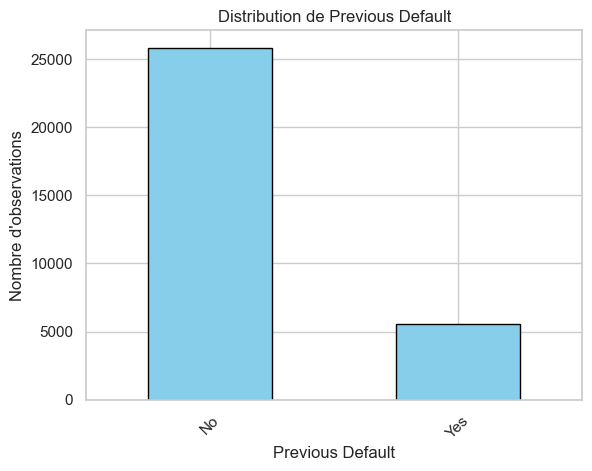

--- Previous Default ---
Previous Default
No     25830
Yes     5585
Name: count, dtype: int64




In [76]:
analyse_categorielle(data, "Previous Default")

Seulement 17,5% des clients avait fait un defaut sur leur credit precedemment.

### Analyse de Loan-to-Income Group (Montant du pret/Revenu)

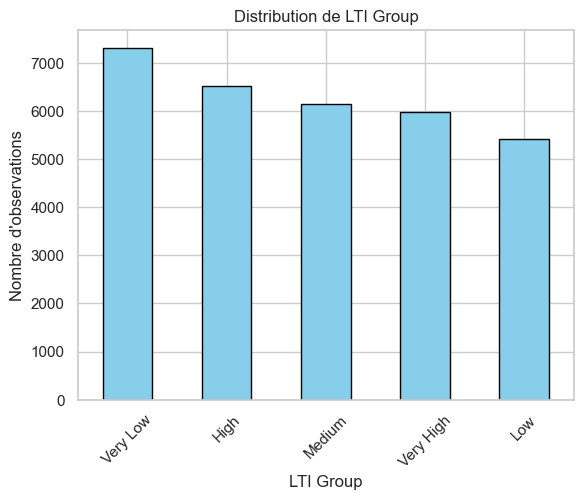

--- LTI Group ---
LTI Group
Very Low     7321
High         6528
Medium       6157
Very High    5981
Low          5428
Name: count, dtype: int64




In [77]:
analyse_categorielle(data, "LTI Group")

### Loan Grade

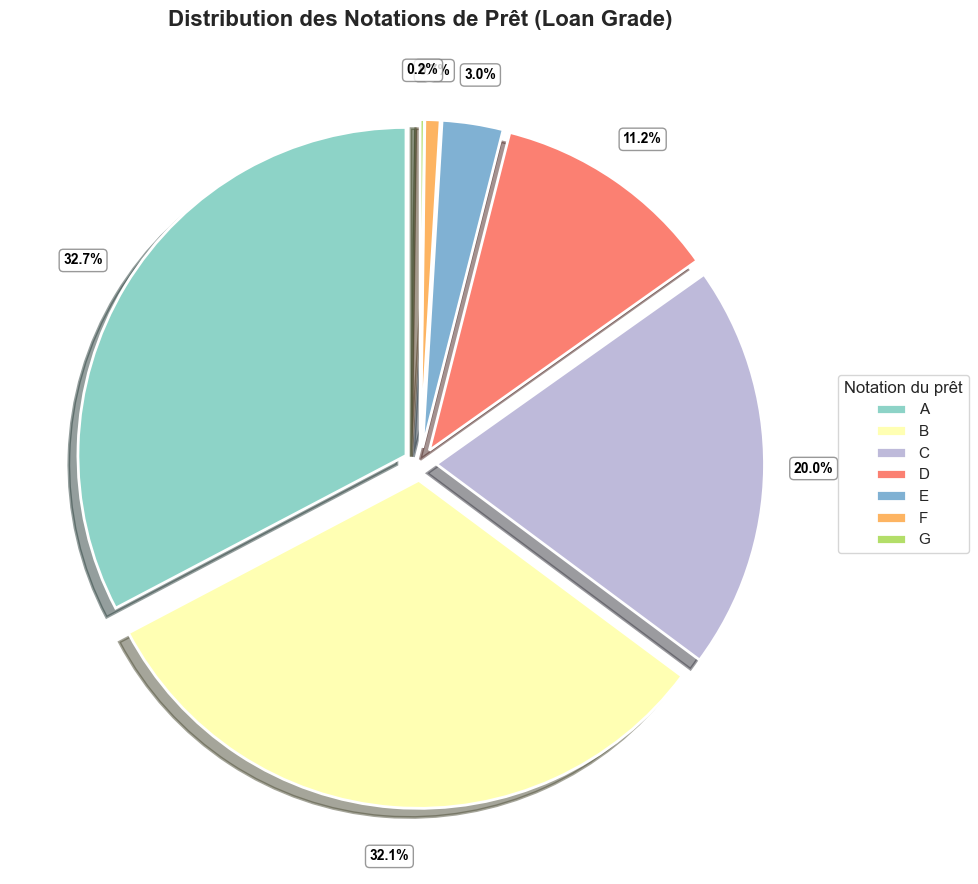

In [79]:
import matplotlib.pyplot as plt

# Calcul des statistiques par grade
grade_stats = (
    data.groupby('Loan Grade')['Default Status']
    .agg(Default_Rate='mean', Count='count')
    .reset_index()
)

# Création des labels intérieurs (grade + effectif)
labels_interieurs = [
    f"{grade}\n(n={count})"
    for grade, count in zip(grade_stats['Loan Grade'], grade_stats['Count'])
]

# Figure
fig, ax = plt.subplots(figsize=(12, 9))

# Palette dynamique
colors = plt.cm.Set3.colors[:len(grade_stats)]

# Explosion légère
explode = [0.05] * len(grade_stats)

# Camembert
wedges, texts, autotexts = ax.pie(
    grade_stats['Count'],
    labels=labels_interieurs,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=1.15,
    colors=colors,
    explode=explode,
    textprops={'fontsize': 11, 'weight': 'bold', 'color': 'white'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    shadow=True
)

# Style des pourcentages
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)
    autotext.set_bbox(dict(
        boxstyle='round,pad=0.3',
        facecolor='white',
        edgecolor='gray',
        alpha=0.8
    ))

# Titre
ax.set_title(
    "Distribution des Notations de Prêt (Loan Grade)",
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Légende
ax.legend(
    wedges,
    grade_stats['Loan Grade'],
    title="Notation du prêt",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

### Interprétation

**Analyse de la répartition:**
- La majorité des emprunteurs reçoivent une notation entre A et C (environ 75 %), indiquant que la plupart des demandes de prêt proviennent de profils considérés comme moins risqués.
- Les grades D, E, F et G représentent une proportion plus faible, correspondant aux profils plus risqués.

**Effectivité de la notation:**
- La notation du prêt **reflète efficacement le risque de défaut**: on observe une tendance croissante du taux de défaut avec la dégradation de la notation.
- Les grades supérieurs (meilleure notation = moins de risque) ont les taux de défaut les plus bas.
- Les grades inférieurs (pire notation = plus de risque) ont les taux de défaut les plus élevés.
- Cette progression monotone confirme que le système de notation discrimine bien les emprunteurs en fonction de leur risque de défaut.

### Detection d'outliers

Les valeurs aberrantes ont été détectées à l’aide de boxplots et de la méthode de l’IQR.Pour les variables financières (revenu, montant du prêt, taux d’intérêt, etc.), les valeurs extrêmes ont été conservées car elles reflètent la réalité. Ces variables sont asymétriques à droite à cause de quelques valeurs très élevées. Garder ces valeurs permet de mieux analyser les profils à haut revenu ou à risque élevé. Leur présence montre une forte hétérogénéité des emprunteurs, ce qui est normal dans ce type de données.

Annual Income: 1448 outliers (4.61%) | range [-21475.00, 140885.00]

Loan Amount: 1621 outliers (5.16%) | range [-6250.00, 23750.00]

Interest Rate: 6 outliers (0.02%) | range [-0.47, 21.85]

Loan % of Income: 610 outliers (1.94%) | range [-0.12, 0.44]

Credit History Length (Years): 1108 outliers (3.53%) | range [-4.50, 15.50]



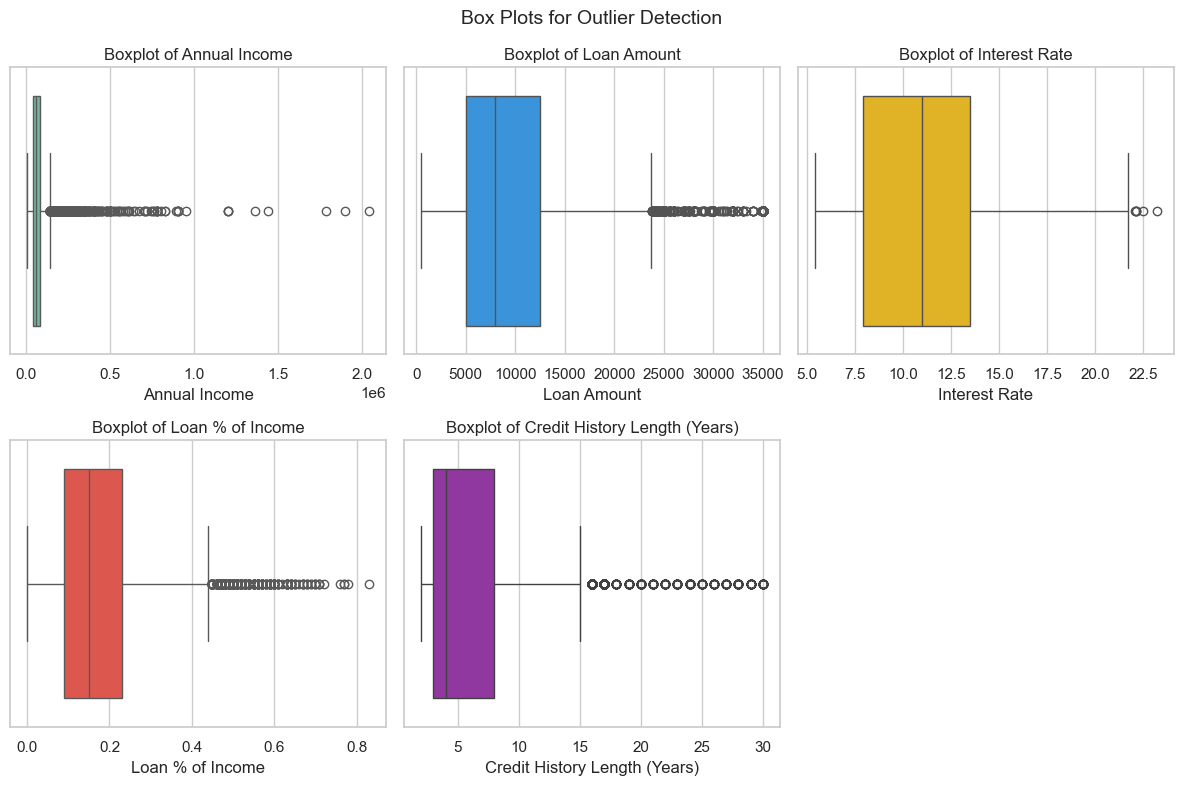

In [81]:
# Columns selected for outlier analysis
cols = ["Annual Income",'Loan Amount', 'Interest Rate', 'Loan % of Income','Credit History Length (Years)']

# Function to detect outliers using the Interquartile Range (IQR) method
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

# Print summary of outliers for each column
for col in cols:
    count, low, high = detect_outliers_iqr(data, col)
    print(f"{col}: {count} outliers ({(count/len(data))*100:.2f}%) | range [{low:.2f}, {high:.2f}]")
    print()

# Visualize distributions using boxplots
colors = ['#66c2a5','#2196F3', '#FFC107', '#F44336', '#9C27B0']
plt.figure(figsize=(12,8))

# Fix: Start subplot index from 1 and use 'i' for color index
for i, col in enumerate(cols):
    plt.subplot(2, 3, i + 1) # i + 1 to make the subplot index 1-based

    sns.boxplot(x=data[col], color=colors[i]) # Use 'i' to select color from the list
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.suptitle('Box Plots for Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

# II. Statistique descriptives bivariées

In [ ]:
from statistique_descriptive import bivarié_cat_num
from statistique_descriptive import bivarié_cat_cat
from scipy import stats

### Objectif n°1: Comment la notation des prêts reflète-t-elle efficacement le risque de défaut de paiement de l'emprunteur?

In [ ]:
def default_summary(data, group_col):
    return data.groupby(group_col).agg(
        # Nombre total d'emprunteurs dans chaque groupe (taille de l'échantillon — critique pour la fiabilité)
        total=('Default Status', 'count'),

        # Nombre d'emprunteurs ayant fait défaut (somme des 1 dans la cible binaire)
        defaults=('Default Status', 'sum'),

        # Taux de défaut = moyenne de la cible binaire = proportion de défauts dans le groupe
        default_rate=('Default Status', 'mean'),

        # Borne inférieure de l'intervalle de confiance à 95% pour le taux de défaut.
        # Utilise un intervalle de Wald (approximation normale) via statsmodels.proportion_confint.
        # Des intervalles plus larges signalent des estimations moins fiables (généralement pour les petits groupes).
        ci_lower=('Default Status', lambda x: proportion_confint(x.sum(), len(x), alpha=0.05)[0]),

        # Borne supérieure de l'intervalle de confiance à 95% pour le taux de défaut.
        ci_upper=('Default Status', lambda x: proportion_confint(x.sum(), len(x), alpha=0.05)[1])
    ).reset_index()  # Aplatit l'index du groupby en une colonne ordinaire pour un affichage facile

In [ ]:
#résumé par grade de prêt
pd.set_option('display.float_format', '{:,.2f}'.format)
default_summary(data, 'Loan Grade')

In [ ]:
# Calcule le taux de défaut par grade de prêt
grade_stats = data.groupby('Loan Grade')['Default Status'].agg(['mean', 'count']).reset_index()

# Renomme pour plus de clarté
grade_stats.columns = ['Loan Grade', 'Default Rate', 'Count']

# Taux de base global
baseline = data['Default Status'].mean()

plt.figure(figsize=(8,5))

# Diagramme en barres avec une palette de couleurs modifiée
# Exemples : 'Blues_r', 'Reds_r', 'coolwarm', 'viridis', 'Set2', 'muted', 'pastel'
sns.barplot(
    data=grade_stats,
    x='Loan Grade',
    y='Default Rate',
    palette='Blues_r'      # ← Couleurs modifiées : dégradé de bleu (plus foncé pour les grades élevés)
)

# Ajoute la ligne du taux de base
plt.axhline(baseline, linestyle='--', color='red', label=f'Valeur de référence ({baseline:.1%})')

# Ajoute les annotations (taux + taille de l'échantillon)
for i, row in grade_stats.iterrows():
    plt.text(i, row['Default Rate'] + 0.02,
             f"n={int(row['Count'])}\n{row['Default Rate']:.1%}",
             ha='center', fontsize=9)

plt.title('Taux de défaut par grade de prêt', fontsize=12)  # Titre en français
plt.ylabel('Taux de défaut')
plt.xlabel('Grade de prêt')
plt.legend()

plt.tight_layout()
plt.show()

### interprétation:
1. Observation des tendances
- Le graphique montre une séparation très nette entre les grades A–C (faible risque) et D–G (risque élevé) :
- Grades A, B, C : taux de défaut compris entre environ 12 % et 20 %.
- Grades D, E, F : taux de défaut beaucoup plus élevés, de 58 % à 72 %.
- Le taux de défaut de référence global est de 21,6 %.
- Cette rupture brutale entre C et D indique que le système de notation ne suit pas une échelle linéaire, mais intègre probablement un seuil de risque strict (par exemple, un score minimum imposé par les politiques de prêt).

2. Déséquilibre des effectifs
- La majorité des prêts (n=10 274 pour A ) se concentre sur les grades A–C.
- Les grades à haut risque (D–F) ne représentent qu’un faible nombre d’observations (par exemple n=943 pour E, n=234 pour F, etc.).
- Ce déséquilibre reflète une stratégie de prêt réaliste : les institutions évitent d’accorder massivement des prêts aux profils les plus risqués.

3. Limites méthodologiques
- Les petits effectifs dans les grades D–F rendent les estimations de taux de défaut moins fiables (intervalles de confiance larges). Une interprétation prudente s’impose.
- La valeur de référence globale (21,6 %) est tirée vers le bas par la surreprésentation des grades A–C.

4. Conclusion stratégique
 Le grade de prêt est un indicateur puissant et synthétique du risque de défaut. Il agrège efficacement des informations financières et comportementales des emprunteurs. Pour une gestion du risque optimale :
- Renforcer la segmentation : traiter les grades A–C et D–G comme deux populations distinctes dans les modèles de scoring.
- Collecter plus de données sur les grades D–G pour affiner les estimations.
- Envisager des seuils d’acceptation plus stricts si le taux de défaut observé (>58 %) est jugé trop élevé.

## Correlation des variables numériques avec l'échellon du pret

In [ ]:
grade_numeric = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
data['grade_numeric'] = data['Loan Grade'].map(grade_numeric)
features = {
    'Annual Income': 'Income',
    'Loan % of Income': 'LTI',
    'Employment Length (Years)': 'Employment Length',
    'Credit History Length (Years)': 'Credit History'
}

print(f"{'Variable':<25} {'Correlation avec Loan Grade':<25} {'R²':<10}")
print("-" * 60)

for col, label in features.items():
    r, p = stats.pearsonr(data['grade_numeric'], data[col])
    print(f"{label:<25} {r:<25.4f} {r**2:<10.4f}")

prev_numeric = (data['Previous Default'] == 'Yes').astype(int)
r, p = stats.pearsonr(data['grade_numeric'], prev_numeric)
print(f"{'Previous Default':<25} {r:<25.4f} {r**2:<10.4f}")

### Analyse de la raison des prets

In [ ]:

plt.figure(figsize=(10,6))

order = data['Loan Purpose'].value_counts().index

sns.countplot(
    data=data,
    x='Loan Purpose',
    order=order,
    palette='Blues_r'
)

plt.title('Loan Purpose Distribution')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Borrowers')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


On observe que la plus grande proportion des prêts contractés par les individus est destinée au financement de l’éducation.

### Analyse du défaut de paiement en fonction des motifs de souscription des prêts

In [ ]:
ct = pd.crosstab(
    data['Loan Purpose'],
    data['Default Status'],
    normalize='index'
)

ct = ct.loc[order]

ct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='coolwarm'
)

plt.title('Default Rate by Loan Purpose')
plt.ylabel('Proportion')
plt.xlabel('Loan Purpose')
plt.xticks(rotation=30, ha='right')
plt.legend(['No Default', 'Default'])
plt.tight_layout()
plt.show()


### Analyse du taux de selon le statut de logement des emprunteurs.

In [ ]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x='Home Ownership',
    y='Default Status',
    data=data,
    order=['RENT', 'OWN', 'MORTGAGE'],
    palette=['#F44336', '#2196F3', '#FFC107'],
    errorbar=None
)

# Add labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Default Rate en fonction Home Ownership')
plt.xlabel('Home Ownership Status')
plt.ylabel('Default Probability')
plt.show()


On remarque que la base de donnée est très deséquilibré comme on peut le voir ici environ 18% des prets des individus ne sont pas remboursées

In [ ]:
data['Previous Default'].value_counts(normalize=True) * 100

### Defaut de paiement en fonction des précedents défauts

In [ ]:
sns.barplot(x='Previous Default', y='Default Status', data=data, errorbar=None, color='#9C27B0')
plt.title('Default Rate by Previous Default History')
plt.show()

On voit ainsi que la situation de defaut precedent d'un client constitue une variable très importante pour anticiper si un individu paiera sa dette ou non.

### Default rate en fonction de variables importantes

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Create LTI Group before using it
data['LTI Group'] = pd.qcut(data['Loan % of Income'], q=5, labels=["Very Low","Low","Medium","High","Very High"])

# Create Income Group before using it
data['Income Group'] = pd.qcut(data['Annual Income'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# 1. Previous Default x Loan Grade
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grouped1 = (data.groupby(['Loan Grade', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))

sns.barplot(data=grouped1, x='Loan Grade', y='default_rate',
            hue='Previous Default', order=grade_order,
            ax=axes[0], palette=['steelblue', 'coral'])
axes[0].set_title('Default Rate by Grade fonction Previous Default')
axes[0].set_xlabel('Loan Grade')
axes[0].set_ylabel('Default Rate')
axes[0].set_ylim(0, 1)

# 2. Previous Default x LTI Group
grouped2 = (data.groupby(['LTI Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))
lti_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped2, x='LTI Group', y='default_rate',
            hue='Previous Default', order=lti_order,
            ax=axes[1], palette=['steelblue', 'coral'])
axes[1].set_title('Default Rate by LTI fonction Previous Default')
axes[1].set_xlabel('LTI Group')
axes[1].set_ylabel('Default Rate')
axes[1].set_ylim(0, 1)

# 3. Previous Default x Income Group
grouped3 = (data.groupby(['Income Group', 'Previous Default'])['Default Status']
              .mean()
              .reset_index()
              .rename(columns={'Default Status': 'default_rate'}))
income_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
sns.barplot(data=grouped3, x='Income Group', y='default_rate',
            hue='Previous Default', order=income_order,
            ax=axes[2], palette=['steelblue', 'coral'])
axes[2].set_title('Default Rate by Income fonction Previous Default')
axes[2].set_xlabel('Income Group')
axes[2].set_ylabel('Default Rate')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Default rate versus Age Group

In [ ]:
bivarié_cat_cat(data, "Age Group", "Default Status")

On remarque que les groupes d'age les plus en defaut de paiements sont les plus jeunes agée de 18 à 25 ans.

### Structure de la correlation

In [ ]:
# This heatmap visualizes the correlation between all numeric features.
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de correlation des variables numériques')
plt.show()

Comme nous l'avons précedemment vu, la nature du credit précedent de la personne influence grandement s'il sera en defaut ou non.

## Creation du modèle

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["Default Status"])
y = data["Default Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

### Fonction de scoring

$$
WoE_i = \ln \left( \frac{ \frac{n_i^{(non\_defaut)}}{N^{(non\_defaut)}} }{ \frac{n_i^{(defaut)}}{N^{(defaut)}} } \right)
$$

- WoE > 0  → catégorie "bonne" (plus de non-défauts)
- WoE < 0  → catégorie "risquée" (plus de défauts)
- WoE ≈ 0  → neutre

In [ ]:
target = "Default Status"
features = [
    "Home Ownership",
    "Loan Purpose",
    "Loan Grade",
    "LTI Group",
    "Income Group",
    "Age Group",
    "Interest Rate Group",
    "Previous Default",
    "Credit History Length (Years)"
]

In [ ]:
def fonction_scoring(X, y, col):
    tab = pd.crosstab(X[col], y)
    
    tab.columns = ['non_def', 'def']
    
    tab['dist_non_def'] = tab['non_def'] / tab['non_def'].sum()
    tab['dist_def'] = tab['def'] / tab['def'].sum()
    
    tab['WoE'] = np.log(tab['dist_non_def'] / tab['dist_def'])
    tab['IV'] = (tab['dist_non_def'] - tab['dist_def']) * tab['WoE']
    
    return tab, tab['IV'].sum()

In [ ]:
X_train_woe = pd.DataFrame()
X_test_woe = pd.DataFrame()

In [ ]:
woe_maps = {}

for col in features:
    table, _ = fonction_scoring(X_train, y_train, col)
    
    # sauver le mapping WoE
    woe_maps[col] = table['WoE']
    
    # appliquer transformation
    X_train_woe[col] = X_train[col].map(table['WoE'])

In [ ]:
for col in features:
    table = fonction_scoring(X_train, y_train, col)[0]
    X_test_woe[col] = X_test[col].map(table['WoE'])

In [ ]:
X_train_woe = X_train_woe.fillna(0)
X_test_woe = X_test_woe.fillna(0)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_woe, y_train)

### Prediction du score

In [ ]:
y_proba = model.predict_proba(X_test_woe)[:,1]

### Transformation en score de defaut

In [ ]:
score = 300 + (y_proba - y_proba.min()) * 550 / (y_proba.max() - y_proba.min())

In [ ]:
score

In [ ]:
import matplotlib.pyplot as plt

plt.hist(score, bins=30)